In [ ]:
import os
from google.colab import files
print("Kaggle.Json File")
files.upload() #Downloaded kaggle.json legacy api key from the kaggle acount website and uploaded it so I can use the Intel Image dataset

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading dataset...")
!kaggle datasets download -d puneet6060/intel-image-classification #download the dataset

print("Unzipping...")
import zipfile
with zipfile.ZipFile('intel-image-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/intel_data') #zip_file shanenigans

print("Data is ready.")

Kaggle.Json File


Saving kaggle.json to kaggle (3).json
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping...
Data is ready.


In [ ]:
#Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

Classic importing of some of the libraries we're going to use

In [ ]:
train_dir = '/content/intel_data/seg_train/seg_train'
test_dir = '/content/intel_data/seg_test/seg_test'

#matching the datas and transforming them to fit our needs
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transform)

#creating the loaders (mini batch using 32 batches)
BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data Loaded: {len(train_data)} Training images, {len(test_data)} Test images") #checking whether it achieved successful upload

Data Loaded: 14034 Training images, 3000 Test images


Checking and seeing 14K training images and 3K test images.

In [ ]:
print("Classes:", train_data.classes)
print("Class to idx:", train_data.class_to_idx)

images, labels = next(iter(train_loader))
print("Batch:", images.shape, labels.shape)  # expected: [32, 3, 150, 150] - 32 batch size, 3 channels for colors RGB, 150 height and 150 width

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Class to idx: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Batch: torch.Size([32, 3, 150, 150]) torch.Size([32])


**We have 6 classes in Intel. Building start at 0, forest is 1**.
we indexed them so we could use these classes later on in our CNN model training.

In [ ]:
from torch.utils.data import random_split

val_ratio = 0.15 #15% of data is held back and only used for checking progress.
n_total = len(train_data)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_subset, val_subset = random_split(train_data, [n_train, n_val])
#batch size is a global int changes to whatever we want also used to benefit for our cnn
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
#checking to see the split between them, cool trick.
print("Split:", len(train_subset), "train,", len(val_subset), "val")

Split: 11929 train, 2105 val


In [ ]:
import torch.nn as nn
import torch.optim as optim

#The CNN ITSELF
class CNN1(nn.Module):
    def __init__(self, num_classes=6):
        super(CNN1, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        #Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
#Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN1(num_classes=6).to(device)
#crossentropy and using ADAM
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2) #using factor of 0.5 if it plateaus, waiting 2 ticks or epochs to change.

print("Model created with forward() as the movement")

Model created with forward() as the movement


In [ ]:
#Managing the Learning rate & amt of epochs. This will be important for seeing different results later for us. prehaps using
#Other learning rates or more/less epochs

lr = 1e-3; #standard point for ADAM
epochs = 12;

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

#Scheduler to reduce the learnin rate if it loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2 #if model is stuck, cutting half of the learning rate. Patience is waiting 2 epochs of no improvement before changing
)

I gave them 12 epochs because I ran 10 epochs one time as a test and the model didnt finish the learning in epochs, but I didn't want to change the lr.

In [ ]:
import time #use it to time the epochs

#Setup list to store history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"Starting training for {epochs} epochs")
start_time = time.time()

for epoch in range(epochs):
    # Training Phase
    model.train() #using the dropout
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #resetting the gradients
        outputs = model(images) #predict
        loss = criterion(outputs, labels) #calculate loss
        loss.backward() #this is the backprop
        optimizer.step() #updating the weights

        #tracking the metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    #calculate the average for each epoch (specifically this epoch)
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Validation Phase
    model.eval() #turning off dropout for testing now...
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): #faster, saves memory
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    # SCHEDULER & LOGGING
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.5f} | "
          f"Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | Val Loss: {val_loss:.4f}")

print(f"training is done: total time: {(time.time() - start_time)/60:.2f} min")

Starting training for 12 epochs
Epoch [1/12] | LR: 0.00100 | Train Acc: 59.6% | Val Acc: 69.5% | Val Loss: 0.8648
Epoch [2/12] | LR: 0.00100 | Train Acc: 74.6% | Val Acc: 80.5% | Val Loss: 0.5511
Epoch [3/12] | LR: 0.00100 | Train Acc: 79.8% | Val Acc: 83.1% | Val Loss: 0.5006
Epoch [4/12] | LR: 0.00100 | Train Acc: 82.5% | Val Acc: 84.1% | Val Loss: 0.4479
Epoch [5/12] | LR: 0.00100 | Train Acc: 84.7% | Val Acc: 84.9% | Val Loss: 0.4720
Epoch [6/12] | LR: 0.00100 | Train Acc: 86.4% | Val Acc: 85.1% | Val Loss: 0.4611
Epoch [7/12] | LR: 0.00050 | Train Acc: 87.6% | Val Acc: 84.7% | Val Loss: 0.4524
Epoch [8/12] | LR: 0.00050 | Train Acc: 90.2% | Val Acc: 86.3% | Val Loss: 0.4228
Epoch [9/12] | LR: 0.00050 | Train Acc: 91.7% | Val Acc: 86.9% | Val Loss: 0.4080
Epoch [10/12] | LR: 0.00050 | Train Acc: 92.8% | Val Acc: 85.8% | Val Loss: 0.4817
Epoch [11/12] | LR: 0.00050 | Train Acc: 93.9% | Val Acc: 86.6% | Val Loss: 0.4387
Epoch [12/12] | LR: 0.00025 | Train Acc: 94.1% | Val Acc: 86.7% 

Nice runtime overall not too bad, and accuracy to val is ~okay-ish

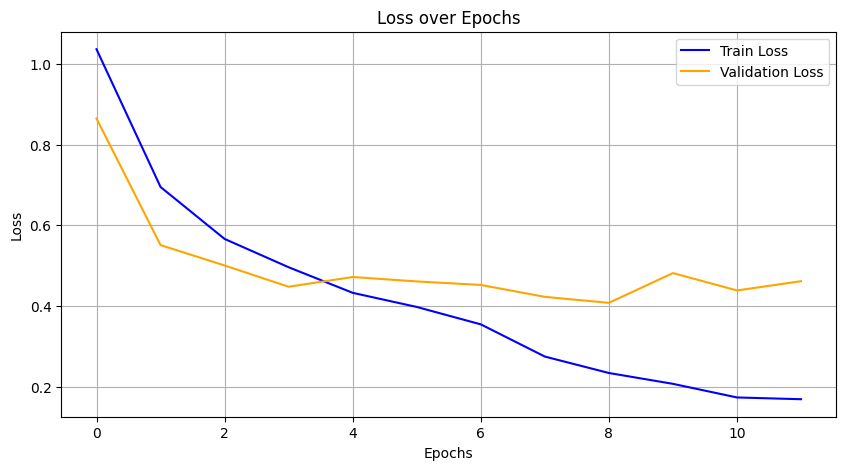

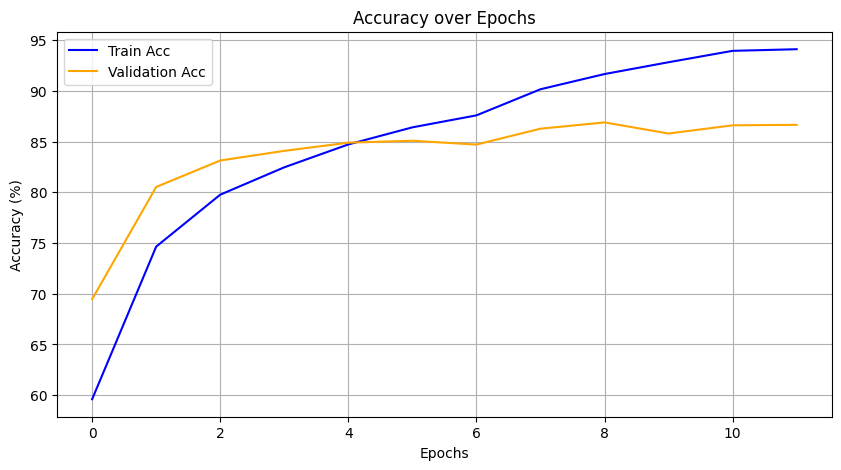

In [ ]:
#plotting the loss over the epochs
plt.figure(figsize=(10, 5)) #making it a bit wider
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(val_losses, label="Validation Loss", color='orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")
plt.grid(True)
plt.show()

#plotting the accuracy over the epochs
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label="Train Acc", color='blue')
plt.plot(val_accs, label="Validation Acc", color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy over Epochs")
plt.grid(True)
plt.show()

Before changing the hyperparameters we will evaluate the Test set + confusion matrix + F1 on the baseline first and then decide further...

classification:

              precision    recall  f1-score   support

   buildings       0.87      0.80      0.83       437
      forest       0.95      0.97      0.96       474
     glacier       0.83      0.82      0.83       553
    mountain       0.82      0.83      0.83       525
         sea       0.89      0.88      0.88       510
      street       0.85      0.90      0.87       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



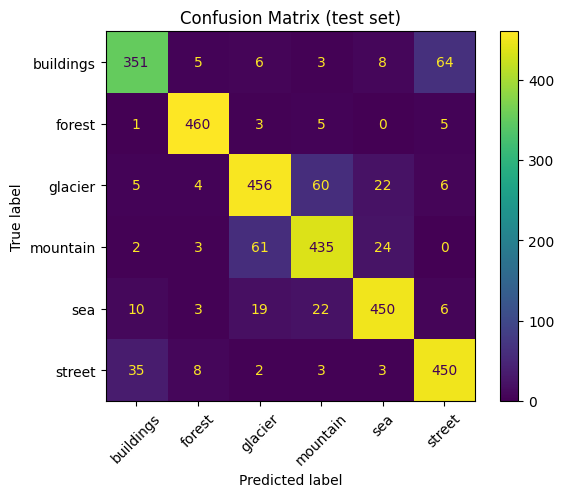

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay #cool ways to do confusion matrix I found online

#model switching to disable dropout
model.eval()
all_preds = []
all_true = []

#just optimizing, for saving memory and speed
with torch.no_grad():
  for x, y in test_loader:
    x = x.to(device) #move images to GPU
    logits = model(x) #get raw scores
    preds = torch.argmax(logits, dim=1).cpu().numpy() #taking the highest scor class and move back to cpu

    all_preds.extend(preds)
    all_true.extend(y.numpy()) #keeping the labels

#printing the detail metrics
print("classification:\n")
print(classification_report(all_true, all_preds, target_names=train_data.classes))

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot(xticks_rotation=45) #plotting with rotation so the class names don't overlap above the other
plt.title("Confusion Matrix (test set)")
plt.show()

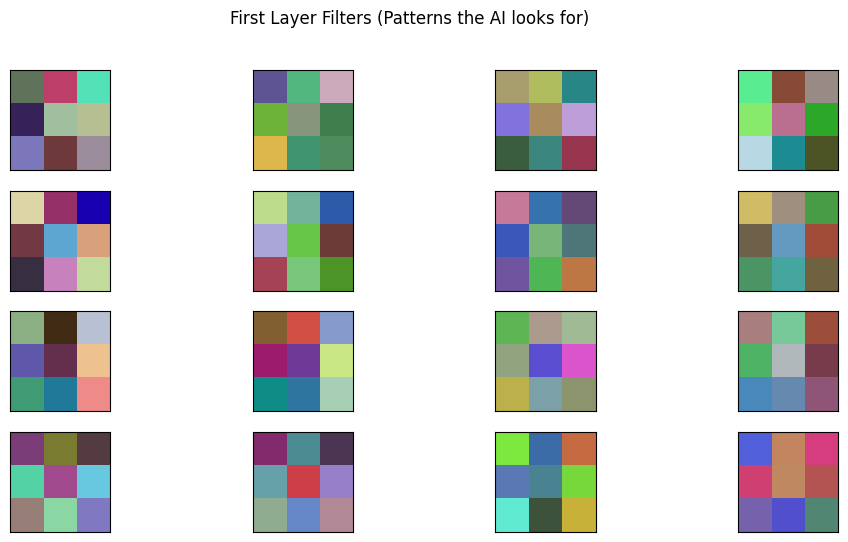

In [ ]:
#Visualization
first_conv_layer = model.features[0]
filters = first_conv_layer.weight.data.cpu()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

plt.figure(figsize=(12,6))
#showing 16 filters out of 32
n_filters = 16
for i in range(n_filters):
  #getting the filter
  f = filters[i]

  #plotting
  ax = plt.subplot(4,4,i+1)
  ax.set_xticks([])
  ax.set_yticks([])

  #Transpose height,width,color to matplotlib
  plt.imshow(f.permute(1,2,0))

plt.suptitle("First Layer Filters (Patterns the AI looks for)")
plt.show()

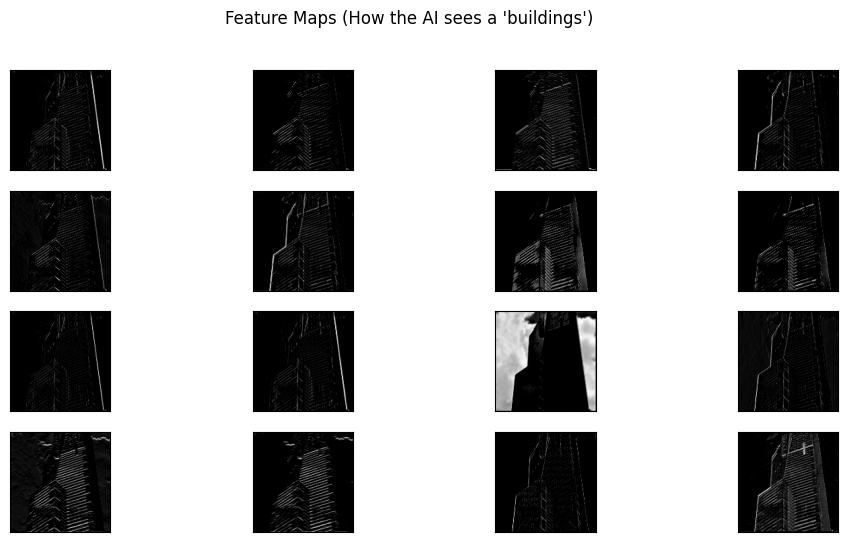

In [ ]:
#Visualization 2
#taking one real image from test set and passing it through the first layer
image, label = test_data[0] #grabbing the fitrs image
image = image.unsqueeze(0).to(device) #add batch dimension

with torch.no_grad():
  feature_maps = model.features[0](image)
  feature_maps = model.features[1](feature_maps)

feature_maps = feature_maps.squeeze(0).cpu()
plt.figure(figsize=(12,6))
for i in range(n_filters):
  ax=plt.subplot(4,4,i+1)
  ax.set_xticks([])
  ax.set_yticks([])

  plt.imshow(feature_maps[i], cmap='gray')

plt.suptitle(f"Feature Maps (How the AI sees a '{test_data.classes[label]}')")
plt.show()

Lets try to change some methods and see whether we get better results.

In [ ]:
import torch.nn as nn
import torch.optim as optim

#The CNN ITSELF
class CNN1(nn.Module):
    def __init__(self, num_classes=6):
        super(CNN1, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        #Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
#Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN1(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("2nd Model is ready now")

#Managing the Learning rate & amt of epochs. This will be important for seeing different results later for us. prehaps using
#Other learning rates or more/less epochs

lr = 3e-4; #standard point for ADAM
epochs = 12;

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

#Scheduler to reduce the learnin rate if it looses plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2 #if model is stuck, cutting half of the learning rate. Patience is waiting 2 epochs of no improvement before changing
)

2nd Model is ready now


In [ ]:
import time #use it to time the epochs

#Setup list to store history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"Starting training for {epochs} epochs")
start_time = time.time()

for epoch in range(epochs):
    # Training Phase
    model.train() #using the dropout
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #resetting the gradients
        outputs = model(images) #predict
        loss = criterion(outputs, labels) #calculate loss
        loss.backward() #this is the backprop
        optimizer.step() #updating the weights

        #tracking the metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    #calculate the average for each epoch (specifically this epoch)
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Validation Phase
    model.eval() #turning off dropout for testing now...
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): #faster, saves memory
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    # SCHEDULER & LOGGING
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.5f} | "
          f"Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | Val Loss: {val_loss:.4f}")

print(f"Training done, total time: {(time.time() - start_time)/60:.2f} min")

Starting training for 12 epochs
Epoch [1/12] | LR: 0.00030 | Train Acc: 61.9% | Val Acc: 75.2% | Val Loss: 0.6895
Epoch [2/12] | LR: 0.00030 | Train Acc: 75.7% | Val Acc: 79.4% | Val Loss: 0.5524
Epoch [3/12] | LR: 0.00030 | Train Acc: 80.3% | Val Acc: 83.2% | Val Loss: 0.4808
Epoch [4/12] | LR: 0.00030 | Train Acc: 82.1% | Val Acc: 80.2% | Val Loss: 0.5326
Epoch [5/12] | LR: 0.00030 | Train Acc: 84.1% | Val Acc: 85.8% | Val Loss: 0.4139
Epoch [6/12] | LR: 0.00030 | Train Acc: 86.1% | Val Acc: 86.5% | Val Loss: 0.4073
Epoch [7/12] | LR: 0.00030 | Train Acc: 87.2% | Val Acc: 85.2% | Val Loss: 0.4102
Epoch [8/12] | LR: 0.00030 | Train Acc: 88.6% | Val Acc: 85.5% | Val Loss: 0.3944
Epoch [9/12] | LR: 0.00030 | Train Acc: 89.7% | Val Acc: 86.5% | Val Loss: 0.3894
Epoch [10/12] | LR: 0.00030 | Train Acc: 91.3% | Val Acc: 87.0% | Val Loss: 0.3949
Epoch [11/12] | LR: 0.00030 | Train Acc: 92.1% | Val Acc: 86.7% | Val Loss: 0.3821
Epoch [12/12] | LR: 0.00030 | Train Acc: 93.0% | Val Acc: 85.4% 